## LangGraph Basics

### Simple Graph using LangGraph

#### First step

State - 

first, define the state of the graph.

The state schema serves as the input schema for all nodes and edges in the graph

let's use the TypedDict class from python's typing module as our schema, which provides type hints for the keys

In [1]:
from typing_extensions import TypedDict

class stateSchema(TypedDict):
    graph_info:str

Nodes

Nodes are just python functions

The first positional argument is the state, as defined above.

Because the state is TypedDict with schema as defined above, each node can access the key, graph_state with stateSchema['graph_state].

Each Node retruns a new value of the state 'graph_state'

By default, the new value returned by each node will override the prior state value.

In [2]:
def start_play(state:stateSchema):
    print("Start_Play node has been initiated")
    return {"graph_info":state['graph_info'] + " - I am planning to play"}

def Football_play(state:stateSchema):
    print("Footaball node has been called and initiated")
    return {"graph_info":state['graph_info'] + "- I am planning to play football"}

def Boxing_play(state:stateSchema):
    print("Boxing node has been called and initiated")
    return {"graph_info":state['graph_info'] + " - I am planning to play Boxing"}

In [ ]:
import random
from typing import Literal

def random_play(state:stateSchema)->Literal['Football', 'Boxing']: # tells both Python type checkers and LangGraph that this function will return only one of two exact strings: "Football" or "Boxing"
    graph_info = state['graph_info']

    if random.random() > 0.5:
        return "Football" # name of the node we will define below
    else:
        return "Boxing"

### Graph Contruction

Now, we build the graph from our component defined above. 

The StateGraph class is the graph class that we can use. 

First, we initialize a StateGraph with the stateSchema class we have defined above. 

Then, we add out nodes and edges. 

We use the START node, a special node that sends user input to the graph to indicate where to start our graph. 

The END node is a special node that represents a terminal node.

Finally, we compile our graph to perform a few basic checks on the graph structure. 

we can visualize the graph as a mermaid diagram

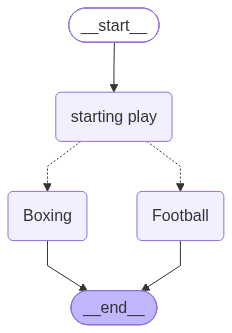

In [4]:
from IPython.display import Image, display # to display the graph
from langgraph.graph import StateGraph, START, END

# building the graph

graph = StateGraph(stateSchema)

# adding the nodes

graph.add_node("starting play", start_play) # the name of the node is starting play
graph.add_node("Football", Football_play)
graph.add_node("Boxing", Boxing_play)

# schedule the flow of the graph

graph.add_edge(START, "starting play")
graph.add_conditional_edges("starting play", random_play) ## to decide which node to pick from the above function
graph.add_edge("Football", END)
graph.add_edge("Boxing", END)

# compile the graph

graph_build = graph.compile()


# view the graph

display(Image(graph_build.get_graph().draw_mermaid_png()))


#### Graph Invocation

In [5]:
graph_build.invoke({"graph_info":"heya"})

Start_Play node has been initiated
Footaball node has been called and initiated


{'graph_info': 'heya - I am planning to play- I am planning to play football'}

### Simple chatbot using Langraph

In [6]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

## reducers
from typing import Annotated # : Attaches framework-specific metadata to a type without changing how type checkers treat the base type itself. The first argument is the actual Python type; subsequent arguments are metadata consumed by external tools like Pydantic, FastApi, or LangGraph.
from langgraph.graph.message import add_messages # Reducer 

In [8]:
class State(TypedDict):
    messages:Annotated[list, add_messages] # add message will apend the messages (Human Message, AI Message, Tool Message etc..) example - {messages:[___,____,____]}
    # list - Defines a key named messages in your state dictionary to store the conversation history (HumanMessage, AIMessage, ToolMessage).
    # add_messages - LangGraph Runtime Level: Gives LangGraph the exact reducer function it needs to execute when updating state.

In [ ]:
import os

from dotenv import load_dotenv
load_dotenv()


In [2]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="openai/gpt-oss-20b", temperature=0)
llm
llm.invoke("hey")

AIMessage(content='Hey there! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "hey". We need to respond. The user hasn\'t asked a question. We can respond with a friendly greeting. The user might want to start a conversation. We can ask how we can help.'}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 72, 'total_tokens': 137, 'completion_time': 0.071903166, 'completion_tokens_details': {'reasoning_tokens': 44}, 'prompt_time': 0.003980932, 'prompt_tokens_details': None, 'queue_time': 0.333665038, 'total_time': 0.075884098}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_84bb35977d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0a41d-8748-7932-b77d-d75aac39e37c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 65, 'total_tokens': 137, 'output_token_details': {'reasoning': 44}})

In [11]:
## creating nodes

def simple_bot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

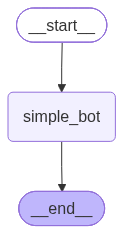

In [13]:
graph = StateGraph(State)

graph.add_node("simple_bot", simple_bot)

# add edge

graph.add_edge(START, "simple_bot")

graph.add_edge("simple_bot", END)

graph_builder = graph.compile()

from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [15]:
## Invocation

graph_builder.invoke({"messages":"Heya!"})

{'messages': [HumanMessage(content='Heya!', additional_kwargs={}, response_metadata={}, id='6953f2af-c2fb-49a1-9147-c87d05f336cf'),
  AIMessage(content='Heya! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'User says "Heya!" It\'s a greeting. We should respond politely. Probably ask how can help.'}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 74, 'total_tokens': 117, 'completion_time': 0.046979503, 'completion_tokens_details': {'reasoning_tokens': 22}, 'prompt_time': 0.037367716, 'prompt_tokens_details': None, 'queue_time': 0.348728261, 'total_time': 0.084347219}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_1074f9ce08', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a09154-af7f-7f62-b335-de29aa076970-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 74, 'output_tokens': 43, 'total_tokens': 117, 'output_token_details': {'reas

In [19]:
## streaming the responses for getting the recent message

for event in graph_builder.stream({"messages":"heya!"}, stream_mode="updates"): # stream_mode has two values 1)'values' 2) 'updates'
    print(event)

{'simple_bot': {'messages': [AIMessage(content='Heya! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'User says "heya!" It\'s a greeting. We should respond politely. Probably a friendly greeting.'}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 74, 'total_tokens': 116, 'completion_time': 0.046408728, 'completion_tokens_details': {'reasoning_tokens': 21}, 'prompt_time': 0.036172226, 'prompt_tokens_details': None, 'queue_time': 0.319615091, 'total_time': 0.082580954}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_9b8528b477', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a09158-c373-78b0-ab84-119d4b446e69-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 74, 'output_tokens': 42, 'total_tokens': 116, 'output_token_details': {'reasoning': 21}})]}}


### Explanation of the whole above code on building the simple bot using langgraph

#### 1. State Schema & Message Appending

Before looking at the execution code, recall your state definition:

Python
class State(TypedDict):
    messages: Annotated[list, add_messages]
When you pass {"messages": "heya!"} to the graph:

Input Normalization: LangGraph receives the input string "heya!". Because add_messages expects message objects, it automatically converts "heya!" into a HumanMessage(content="heya!").

Reducer Execution: add_messages takes the existing state's message list and appends the new HumanMessage to it.

Node Processing (simple_bot):

Python
def simple_bot(state: State):
    return {"messages": [llm.invoke(state['messages'])]}
state['messages'] contains [HumanMessage(content="heya!")].

llm.invoke(...) sends this array to the LLM and returns an AIMessage.

The function returns a dictionary update: {"messages": [AIMessage(...)]}.

State Merge: The graph interceptor passes this returned dictionary to add_messages. Rather than replacing the list, add_messages appends the AIMessage to the existing HumanMessage.

The state now holds:
[HumanMessage(content="heya!"), AIMessage(content="Hello! How can I help you today?")]



#### 2. Graph Invocation vs. Streaming

Invocation (.invoke())
graph_builder.invoke({"messages": "Heya!"}) executes the full graph synchronously from START to END and returns the final state dictionary after all node operations finish.

Output format: A single dictionary containing the accumulated state keys.

Python
{
    "messages": [
        HumanMessage(content="Heya!"),
        AIMessage(content="Hello! How can I assist you today?")
    ]
}
Streaming (.stream())
.stream() yields updates as execution progresses through the graph step-by-step, rather than waiting for the entire run to finish.

Python
for event in graph_builder.stream({"messages": "heya!"}, stream_mode="updates"):
    print(event)

"updates"	Yields only the specific node output dict generated at each step, keyed by node name.	Tracking which node changed what state key.

"values"	Yields the full, cumulative graph state after each node finishes.	Displaying live conversation threads step-by-step.



### State schema with Dataclasses

when we define a langGraph StateGraph, we use a state schema

The state schema represents the structure and types of data our graph will use.

All nodes are expected to communicate with that schema. 

LangGraph offers flexibility in how you define your state schema, accomodaing various python types and validation approaches.

In [20]:
from typing_extensions import TypedDict
from typing import Literal

class State(TypedDict):
    name:str
    game:Literal['football', 'hockey']

In [21]:
def play_game(state:State):
    print("started the game")
    return {"name":state['name'] + " his interested in "}

def football(state:State):
    print('Football has been selected')
    return {"game":"football"}

def hockey(state:State):
    print('Hockey has been selected')
    return {"game":"hockey"}

In [22]:
import random
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

In [23]:
def random_play(state:stateSchema)->Literal['football', 'hockey']: # tells both Python type checkers and LangGraph that this function will return only one of two exact strings: "Football" or "Boxing"

    if random.random() > 0.5:
        return "football" # name of the node we will define below
    else:
        return "hockey"

In [28]:
builder = StateGraph(State)

builder.add_node("Select_game", play_game)
builder.add_node("football", football)
builder.add_node("hockey", hockey)

builder.add_edge(START, "Select_game")
builder.add_conditional_edges("Select_game", random_play)
builder.add_edge('football', END)
builder.add_edge('hockey', END)

graph = builder.compile()

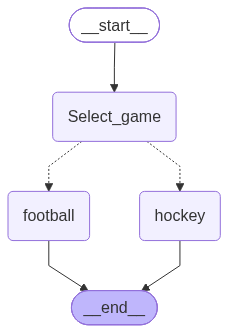

In [30]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
graph.invoke({"name":"Martin"})

started the game
Football has been selected


{'name': 'Martin his interested in ', 'game': 'football'}

In [ ]:
### Data classes

from dataclasses import dataclass

@dataclass
class StateDataClass:
    name:str
    game:Literal["football", "hockey"]

In [38]:
def play_game(state:StateDataClass):
    print("started the game")
    return {"name":state.name + " his interested in "}

def football(state:StateDataClass):
    print('Football has been selected')
    return {"game":"football"}

def hockey(state:StateDataClass):
    print('Hockey has been selected')
    return {"game":"hockey"}

def random_play(state:stateSchema)->Literal['football', 'hockey']: # tells both Python type checkers and LangGraph that this function will return only one of two exact strings: "Football" or "Boxing"

    if random.random() > 0.5:
        return "football" # name of the node we will define below
    else:
        return "hockey"
    
builder = StateGraph(StateDataClass)

builder.add_node("Select_game", play_game)
builder.add_node("football", football)
builder.add_node("hockey", hockey)

builder.add_edge(START, "Select_game")
builder.add_conditional_edges("Select_game", random_play)
builder.add_edge('football', END)
builder.add_edge('hockey', END)

graph = builder.compile()

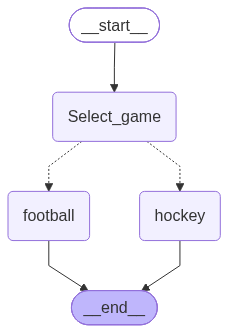

In [39]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [41]:
graph.invoke(StateDataClass(name="Martin", game="football"))

started the game
Hockey has been selected


{'name': 'Martin his interested in ', 'game': 'hockey'}

In [43]:
graph.invoke(StateDataClass(name=123, game="football")) ## Data classes and TypedDict does not provide schema validation at the run time

started the game


TypeError: unsupported operand type(s) for +: 'int' and 'str'

### Pydantic - which is a widely used data validation library in python

In [44]:
from pydantic import BaseModel

In [46]:
class StatePydantic(BaseModel):
    name:str
    game:Literal["football", "hockey"]

In [47]:
def play_game(state:StatePydantic):
    print("started the game")
    return {"name":state.name + " his interested in "}

def football(state:StatePydantic):
    print('Football has been selected')
    return {"game":"football"}

def hockey(state:StatePydantic):
    print('Hockey has been selected')
    return {"game":"hockey"}

def random_play(state:stateSchema)->Literal['football', 'hockey']: # tells both Python type checkers and LangGraph that this function will return only one of two exact strings: "Football" or "Boxing"

    if random.random() > 0.5:
        return "football" # name of the node we will define below
    else:
        return "hockey"
    
builder = StateGraph(StatePydantic)

builder.add_node("Select_game", play_game)
builder.add_node("football", football)
builder.add_node("hockey", hockey)

builder.add_edge(START, "Select_game")
builder.add_conditional_edges("Select_game", random_play)
builder.add_edge('football', END)
builder.add_edge('hockey', END)

graph = builder.compile()

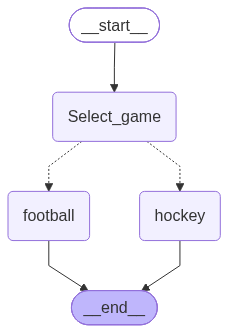

In [48]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
graph.invoke({"name":"Martin", "game":"football"})

ValidationError: 1 validation error for StatePydantic
name
  Input should be a valid string [type=string_type, input_value=123, input_type=int]
    For further information visit https://errors.pydantic.dev/2.13/v/string_type

In [53]:
graph.invoke({"name":123, "game":"football"})

ValidationError: 1 validation error for StatePydantic
name
  Input should be a valid string [type=string_type, input_value=123, input_type=int]
    For further information visit https://errors.pydantic.dev/2.13/v/string_type

### chains in langgraph

building a simple chain using langgraph that uses 4 important concepts

* How to use chat messages as our graph state
* how to use chat models in graph nodes
* how to bind tools to our LLM in chat models
* how to execute the tools call in our graph nodes

In [54]:
from langchain_core.messages import AIMessage, HumanMessage

In [55]:
## Tools - Binding tools to the langgraph

def weather_api(city:str):
    """Get the weather of an city

    Args:
        city (string): city name
    
    Return:
        string: returns the weather of the city
    """
    return f"The weather in {city} is hot!!"

In [58]:
# binding the tool with LLM

llm_tools = llm.bind_tools([weather_api])

In [59]:
llm_tools.invoke([HumanMessage(content="what is the weather of mumbai?")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to call the weather_api function with city "Mumbai".', 'tool_calls': [{'id': 'fc_20245f03-bd9f-4f7b-b752-e7e29e212100', 'function': {'arguments': '{"city":"Mumbai"}', 'name': 'weather_api'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 131, 'total_tokens': 168, 'completion_time': 0.046223112, 'completion_tokens_details': {'reasoning_tokens': 14}, 'prompt_time': 0.007421291, 'prompt_tokens_details': None, 'queue_time': 0.047004528, 'total_time': 0.053644403}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e99e93f2ac', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a091d1-2469-7fc0-b819-f2a04c5835c0-0', tool_calls=[{'name': 'weather_api', 'args': {'city': 'Mumbai'}, 'id': 'fc_20245f03-bd9f-4f7b-b752-e7e29e212100', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'in

In [60]:
# messages as state

from langchain_core.messages import AnyMessage

class State(TypedDict):
    message:Annotated[list, add_messages]

In [ ]:
# node 1
def llm_with_tools(state:State):
    return {"messages":[llm_tools.invoke(state["messages"])]}

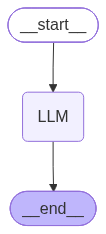

In [69]:
builder_graph = StateGraph(State)

builder_graph.add_node("LLM", llm_with_tools)
builder_graph.add_edge(START, "LLM")
builder_graph.add_edge("LLM", END)

graph = builder_graph.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [70]:
graph.invoke({"message":"what is weather in mumbai?"})

{'message': [HumanMessage(content='what is weather in mumbai?', additional_kwargs={}, response_metadata={}, id='8af9cd30-47eb-40e9-b63a-426a983a4ec5'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to call the weather_api function with city "Mumbai".', 'tool_calls': [{'id': 'fc_e39eb13d-4e5a-4b73-a44e-630acbf8aa92', 'function': {'arguments': '{"city":"Mumbai"}', 'name': 'weather_api'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 130, 'total_tokens': 167, 'completion_time': 0.037838433, 'completion_tokens_details': {'reasoning_tokens': 14}, 'prompt_time': 0.007361575, 'prompt_tokens_details': None, 'queue_time': 0.309269813, 'total_time': 0.045200008}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_c9afb2bdb4', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a091f6-c4ff-7e62-a315-1ed3af9deac4-0', tool_calls=[{'name': 'we

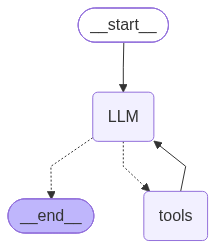

In [97]:
## for making a tool call we need to have a seperate node for the tool

from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition # This utility function implements the standard conditional logic for ReAct-style agents: if the last AIMessage contains tool calls, route to the tool execution node; otherwise, end the workflow. This pattern is fundamental to most tool-calling agent architectures.

Tool = [weather_api]

system_prompt = (
    "You are a helpful assistant. When answering the user's question, "
    "you MUST rely ONLY on the information provided in the tool execution results (ToolMessage). "
    "Do NOT use any outside knowledge or assumptions not present in the tool response."
)

def llm_with_tools(state:State):
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    response = llm_tools.invoke(messages)
    return {"messages": [response]}

class State(TypedDict):
    messages:Annotated[list, add_messages] # pre-built components like tools_condition and ToolNode are hardcoded to look for messages (plural) inside the graph state dictionary.

builder_graph = StateGraph(State)

builder_graph.add_node("LLM", llm_with_tools)
builder_graph.add_node("tools", ToolNode(Tool))
# Add Edges
builder_graph.add_edge(START, "LLM")

# Conditional Edge: LLM -> "tools" OR END
builder_graph.add_conditional_edges("LLM", tools_condition)

# ⭐️ CRITICAL EDGE: Returns Tool output BACK to LLM
builder_graph.add_edge("tools", "LLM")

graph = builder_graph.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [98]:
graph.invoke({"messages":"what is weather in mumbai?"})

{'messages': [HumanMessage(content='what is weather in mumbai?', additional_kwargs={}, response_metadata={}, id='f43ca0dd-46bb-4fcf-969f-618a1a510bed'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to call the weather_api function with city "Mumbai".', 'tool_calls': [{'id': 'fc_54cbc92e-fd01-4504-b938-7f806e384ae6', 'function': {'arguments': '{"city":"Mumbai"}', 'name': 'weather_api'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 177, 'total_tokens': 214, 'completion_time': 0.040579855, 'completion_tokens_details': {'reasoning_tokens': 14}, 'prompt_time': 0.008800483, 'prompt_tokens_details': None, 'queue_time': 0.542826023, 'total_time': 0.049380338}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_851252edc2', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a09213-ac64-7c80-ad37-f8b959474308-0', tool_calls=[{'name': 'w

In [ ]:
# graph.invoke({"messages":"what is AI?"})

{'messages': [HumanMessage(content='what is AI?', additional_kwargs={}, response_metadata={}, id='74c14fc9-9f13-49d5-a7b8-59b0956f1e70'),
  AIMessage(content='**Artificial Intelligence (AI)** is a branch of computer science that focuses on creating systems capable of performing tasks that normally require human intelligence. These tasks include:\n\n| Category | Typical Tasks | Example Applications |\n|----------|---------------|----------------------|\n| **Perception** | Recognizing patterns in data (images, speech, text) | Face recognition, voice assistants, language translation |\n| **Reasoning** | Drawing conclusions, solving problems, planning | Chess engines, autonomous navigation, medical diagnosis |\n| **Learning** | Improving performance from experience | Recommendation engines, fraud detection, self‑driving cars |\n| **Interaction** | Communicating with humans naturally | Chatbots, virtual assistants, customer support |\n\n### Core Concepts\n\n1. **Machine Learning (ML)** – Al

### Langgraph - ChatBot with mulitple tools

creating a chatbot with tools capabilities from arxiv, wikipedia and some custom functions

In [3]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun # The QueryRun objects wrap around the API Wrappers and expose them as runnable LangChain Tools that an LLM can call during a ReAct loop.
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper # The API Wrappers are low-level Python clients that handle the actual network communication with external APIs. They handle parameter formatting, request execution, and parsing raw API responses into structured strings or documents.
import langchain_community.utilities.arxiv as arxiv_module

C:\Users\kumar\AppData\Local\Temp\ipykernel_21500\3115564449.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun # The QueryRun objects wrap around the API Wrappers and expose them as runnable LangChain Tools that an LLM can call during a ReAct loop.


In [4]:
# Force the library to use HTTPS instead of HTTP
arxiv_module.ARXIV_MAX_QUERY_LENGTH = 300
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500) # return top 2 results with individual document length is 500 characters
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [7]:
import urllib.request
import xml.etree.ElementTree as ET
from langchain_core.tools import tool

@tool
def fetch_arxiv_papers_dict(query: str, top_n: int = 3) -> dict:
    """Search arXiv for research papers and return a dictionary mapping paper keys to details.
    
    Args:
        query: The search topic or paper title.
        top_n: Number of results to retrieve.
        
    Returns:
        dict: A dictionary structured as {'Paper 1': {'title': ..., 'published': ..., 'summary': ...}, ...}
    """
    formatted_query = query.replace(" ", "+")
    url = f"https://export.arxiv.org/api/query?search_query=all:{formatted_query}&start=0&max_results={top_n}"
    
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    
    try:
        with urllib.request.urlopen(req) as response:
            xml_data = response.read()
    except Exception as e:
        return {"error": f"Failed to fetch data: {str(e)}"}
        
    root = ET.fromstring(xml_data)
    ns = {'atom': 'http://www.w3.org/2005/Atom'}
    
    entries = root.findall('atom:entry', ns)
    if not entries:
        return {"result": f"No papers found for '{query}'"}
        
    papers_dict = {}
    for idx, entry in enumerate(entries, 1):
        title = entry.find('atom:title', ns).text.strip().replace('\n', ' ')
        summary = entry.find('atom:summary', ns).text.strip().replace('\n', ' ')
        published = entry.find('atom:published', ns).text.strip()[:10]
        
        # Key each entry as 'Paper 1', 'Paper 2', etc.
        papers_dict[f"Paper {idx}"] = {
            "title": title,
            "published": published,
            "summary": summary
        }
        
    return papers_dict

In [14]:
# # Call the tool function directly or via invoke
# papers_data = fetch_arxiv_papers_dict.invoke({"query": "Attention is all you need"})

# # # Enumerate through the returned dictionary keys and paper details
# # for paper_key, paper_details in papers_data.items():
# #     print(f"=== {paper_key} ===")
# #     print(f"Title:     {paper_details['title']}\n")
# #     print(f"Published: {paper_details['published']}\n")
# #     print(f"Summary:   {paper_details['summary'][:150]}...")  # Truncated preview
# #     print("-" * 50)

# print(papers_data)
arxiv.invoke("attention is al you need")

HTTPError: Page request resulted in HTTP 301: None (http://export.arxiv.org/api/query?search_query=attention+is+al+you+need&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=2)

In [12]:
# wikipedia search tool

api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500,headers={"User-Agent": "MyReActAgent/1.0 (mamidiashishkumar@example.com)"})
wiki_loader = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki_loader.name

'wikipedia'

In [13]:
wiki_loader.invoke("deep learning?")

'Page: Deep learning\nSummary: In machine learning, deep learning (DL) focuses on utilizing multilayered neural networks to perform tasks such as classification, regression, and representation learning. The field takes inspiration from biological neuroscience and revolves around stacking artificial neurons into layers and "training" them to process data. The adjective "deep" refers to the use of multiple layers (ranging from three to several hundred or thousands) in the network. Methods used can b'

In [15]:
load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [16]:
# tavily search for LLM
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\kumar\AppData\Local\Temp\ipykernel_21500\352346528.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


c:\Users\kumar\OneDrive\Desktop\Agentic_AI\RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
tavily.invoke("provide me recent football news")

[{'title': 'Football - latest news today, results & video highlights - BBC Sport',
  'url': 'https://www.bbc.com/sport/football',
  'content': "Maldini driving licence suspended after car crash\n\nDaniel Maldini of Cagliari Calcio celebrates after scoring on penalty his first goal during the Serie A match between Atalanta BC and Parma Calcio\n\nAberdeen may be disciplined over fan behaviour\n\nAberdeen players\n\nKane scores 150th Bayern goal in win over Elversberg\n\nHarry Kane celebrating a goal\n\n## Scores & Fixtures\n\n## Scores & Fixtures\n\n## More football news\n\nTwo games, two defeats - are Olid's Man Utd in trouble?\n\nTwo games into the season under new manager Eva Olid, Manchester United look a shadow of the side from last season.\n\nManchester United manager Eva Olid looks on during the Women's Super League against Chelsea\n\nRonaldo demands lifetime bans over Jota chants [...] Liverpool's Luke Chambers\n\nPodcast: Rangers rip through Celtic as Hibs, Hearts & Aberdeen rea

In [30]:
# combine all the tools in the list

tools = [wiki_loader, tavily] ## we can add retriever as a custom tool

In [33]:
llm_with_bind_tools = llm.bind_tools(tools)

In [34]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

llm_with_bind_tools.invoke([HumanMessage(content="what is the current news in football in 15th september 2026")])

AuthenticationError: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'expired_api_key'}}